In [1]:
!git clone https://github.com/NoorMajdoub/Challenge.git

Cloning into 'Challenge'...
remote: Enumerating objects: 657, done.
remote: Counting objects: 100% (184/184), done.
remote: Compressing objects: 100% (151/151), done.
remote: Total 657 (delta 67), reused 82 (delta 27), pack-reused 473 (from 2)
Receiving objects: 100% (657/657), 82.10 MiB | 26.84 MiB/s, done.
Resolving deltas: 100% (287/287), done.


In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.7 MB/s eta 0:00:00


In [3]:
!gunzip /content/Challenge/data/train_compressed.csv.gz

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import umap
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data
import torch.nn.functional as F
from torch_geometric.utils import dropout_edge
from sklearn.metrics import confusion_matrix, classification_report
import time

In [187]:
SEED = 25
np.random.seed(SEED)

In [188]:
sns.set_theme(style='whitegrid')
%matplotlib inline

In [189]:
train = pd.read_csv('/content/Challenge/data/train_compressed.csv')
train.head(10)

,Unnamed: 0,MMP12,C1QB,HLA-DQA1,FCER1G,TYROBP,C1QA,AIF1,C1QC,RNASE1,...,RPLP2,HLA-E,RPL23,SOD1,FAU,SF3B5,RPL30,EZR,RPS14,is_perturbed
0,2162,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.068811,0.011469,0.022937,0.000000,0.057343,0.000000,0.045874,0.000000,0.103217,0.0
1,1609,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.114035,0.022807,0.068421,0.011403,0.068421,0.011403,0.057017,0.000000,0.102631,0.0
2,2564,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.032277,0.008069,0.016138,0.008069,0.008069,0.000000,0.040346,0.000000,0.056485,0.0
3,3739,-0.000659,0.011630,0.021211,-0.035963,0.006977,-0.000553,0.021245,0.022512,-0.002842,...,0.013730,0.006527,0.013013,-0.011065,0.008425,0.019471,0.015423,-0.003363,0.003238,1.0
4,4479,-0.003222,0.007053,-0.008178,-0.010762,0.012637,0.005691,0.026562,0.029989,0.002413,...,0.008791,0.013331,-0.015166,-0.003710,0.022868,-0.040000,-0.017960,-0.007778,0.031176,1.0
5,1035,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.077482,0.008156,0.020390,0.012234,0.053014,0.000000,0.065248,0.000000,0.130496,0.0
6,2261,0.000000,0.000000,0.000000,0.009668,0.029003,0.000000,0.009668,0.000000,0.019336,...,0.038671,0.000000,0.009668,0.000000,0.019336,0.000000,0.038671,0.000000,0.029003,0.0
7,1845,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.079047,0.004940,0.039524,0.009881,0.049405,0.014821,0.074107,0.000000,0.158095,0.0
8,704,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.065887,0.013177,0.079064,0.000000,0.039532,0.013177,0.052709,0.000000,0.079064,0.0
9,1937,-0.044586,-0.041052,0.027368,-0.049324,-0.000272,0.008267,0.010580,0.014410,0.031650,...,0.039133,0.016835,0.003130,-0.008611,0.015272,-0.031787,0.043494,0.003430,0.020616,1.0


In [190]:
edges = pd.read_csv('/content/Challenge/data/edges.csv')
edges.head(10)

,Unnamed: 0,source,target,weight
0,0,0,422,0.848251
1,1,0,304,0.848072
2,2,0,1187,0.846953
3,3,0,748,0.846359
4,4,0,568,0.843545
5,5,1,1763,0.961374
6,6,1,714,0.960014
7,7,1,1525,0.959850
8,8,1,1138,0.959821
9,9,1,17,0.958170


In [191]:
labels = pd.read_csv('/content/Challenge/data/labels.csv')
labels.head(10)

,Unnamed: 0,cell_type
0,2162,0
1,1609,1
2,2564,0
3,3739,1
4,4479,2
5,1035,1
6,2261,0
7,1845,1
8,704,1
9,1937,0


In [229]:
test = pd.read_csv('/content/Challenge/data/test.csv')
test.head(10)

,Unnamed: 0,MMP12,C1QB,HLA-DQA1,FCER1G,TYROBP,C1QA,AIF1,C1QC,RNASE1,...,RPL17,RPLP2,HLA-E,RPL23,SOD1,FAU,SF3B5,RPL30,EZR,RPS14
0,3611,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.023186,0.027050,0.015457,0.015457,0.015457,0.007729,0.000000,0.019322,0.000000,0.042508
1,2259,-0.008862,0.013003,0.005686,-0.016603,0.002834,-0.020747,0.010430,0.003484,-0.015879,...,0.009044,0.027159,-0.009254,-0.008617,0.021681,-0.042438,0.004577,-0.016252,0.016899,0.010045
2,4440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.098321,0.032774,0.000000,0.000000,0.032774,0.098321,0.000000,0.098321,0.000000,0.065547
3,359,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.034008,0.093523,0.000000,0.025506,0.025506,0.051013,0.017004,0.008502,0.000000,0.076519
4,3647,0.030904,0.000157,-0.031614,0.008811,0.013670,0.016430,-0.014317,-0.012735,-0.004560,...,0.018485,0.020522,-0.014522,0.036283,0.001602,0.006018,-0.040911,-0.013530,0.029735,0.047427
5,3257,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.029418,0.058836,0.000000,0.029418,0.014709,0.014709,0.000000,0.058836,0.000000,0.029418
6,2967,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.022852,0.079980,0.000000,0.022852,0.000000,0.022852,0.000000,0.034277,0.000000,0.079980
7,820,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.089470,0.119293,0.014912,0.052191,0.007456,0.059647,0.014912,0.067103,0.000000,0.126749
8,2107,0.003491,0.014932,-0.026763,0.021993,0.004862,-0.006302,-0.002110,0.017705,0.034945,...,-0.019700,0.003411,-0.002695,0.020533,-0.005355,0.038783,-0.004148,-0.018195,0.038894,0.008757
9,703,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.044699,0.074498,0.014900,0.044699,0.007450,0.044699,0.000000,0.052149,0.000000,0.134097


In [193]:
cc = train['is_perturbed'].value_counts()
cc

,count
is_perturbed,
0.0,2624
1.0,1136


In [194]:
pct_perturbed = (cc[1] / len(train)) * 100
pct_perturbed

np.float64(30.21276595744681)

In [195]:
print(f"Clean nodes = {cc[0]}")
print(f"Corrupted Nodes = {cc[1]}")
print(f'Perbutation Rate = {pct_perturbed:.2f}%')

Clean nodes = 2624
Corrupted Nodes = 1136
Perbutation Rate = 30.21%


In [196]:
feature_cols = [c for c in train.columns if c!='is_perturbed']
zero_count = (train[feature_cols] == 0).values.sum()
total_elements = train[feature_cols].size
sparsity = (zero_count / total_elements) * 100
print(f"Feature sparsity  = {sparsity:.2f}%")

Feature sparsity  = 55.09%


In [197]:
all_nodes = pd.concat([edges["source"],edges['target']])
degree_counts = all_nodes.value_counts()
degree_counts

,count
1126,217
1762,160
1273,152
1734,120
166,118
...,...
2202,5
2266,5
30,5
34,5


In [198]:
print(f"Max degree = {degree_counts.max()}")
print(f"Min degee = {degree_counts.min()}")
print(f"Average Degree = {degree_counts.mean():.2f}")

Max degree = 217
Min degee = 5
Average Degree = 11.50


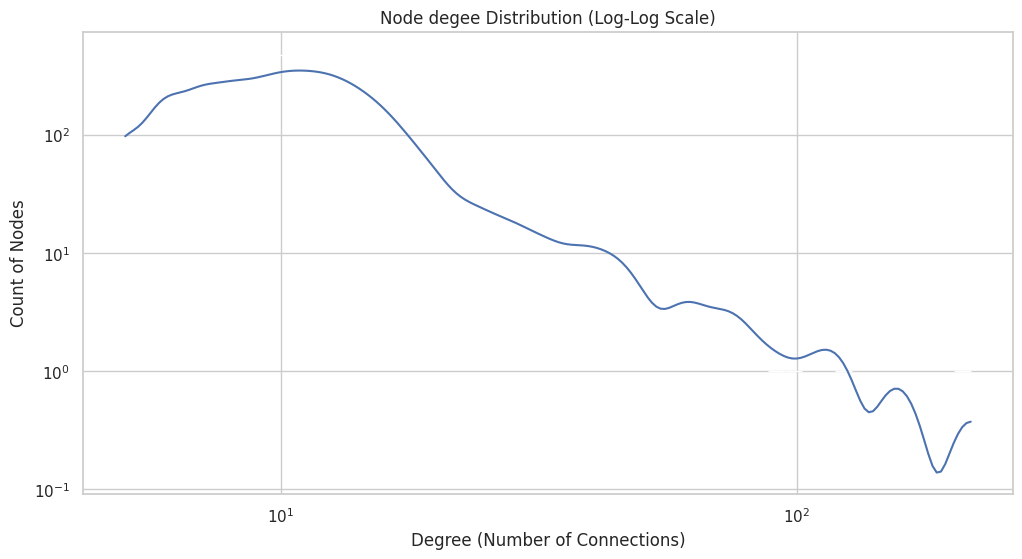

In [199]:
plt.figure(figsize=(12,6))
sns.histplot(degree_counts,bins=50,kde=True,log_scale=(True,True))
plt.title("Node degee Distribution (Log-Log Scale)")
plt.xlabel("Degree (Number of Connections)")
plt.ylabel("Count of Nodes")
plt.show()

In [200]:
sample_genes = train.columns[1:5]
sample_genes

Index(['MMP12', 'C1QB', 'HLA-DQA1', 'FCER1G'], dtype='object')

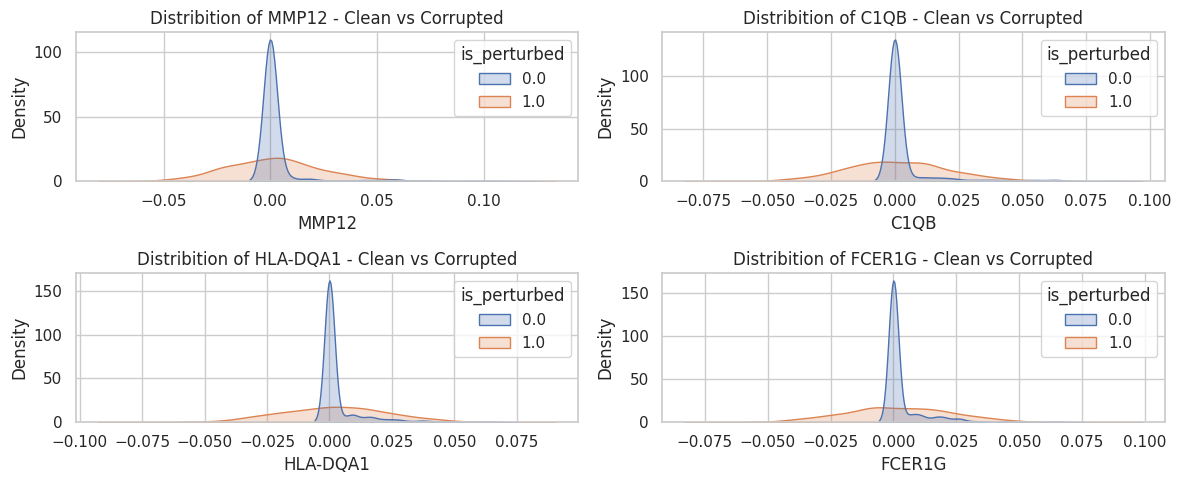

In [201]:
plt.figure(figsize=(12,5))
for i, gene in enumerate(sample_genes):
  plt.subplot(2,2,i+1)
  sns.kdeplot(data=train,x=gene,hue='is_perturbed',fill=True,common_norm=False)
  plt.title(f"Distribition of {gene} - Clean vs Corrupted")
plt.tight_layout()
plt.show()

In [202]:
temp_df = train[['is_perturbed']].copy()
temp_df['cell_type'] = labels['cell_type']

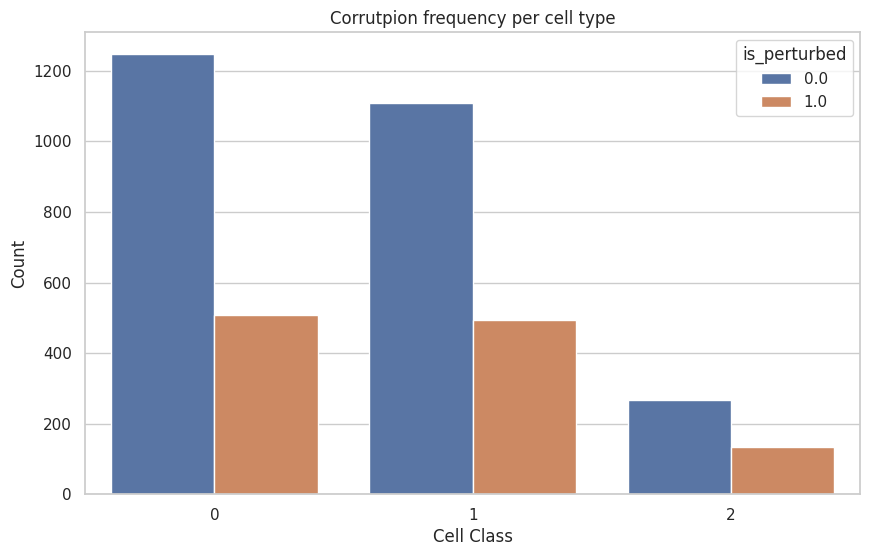

In [203]:
plt.figure(figsize=(10,6))
sns.countplot(data=temp_df,x='cell_type',hue='is_perturbed')
plt.title("Corrutpion frequency per cell type")
plt.xlabel("Cell Class")
plt.ylabel("Count")
plt.show()

In [204]:
n_sample = 2000
train_sample = train.sample(n_sample,random_state=SEED)
train_sample.head()


,Unnamed: 0,MMP12,C1QB,HLA-DQA1,FCER1G,TYROBP,C1QA,AIF1,C1QC,RNASE1,...,RPLP2,HLA-E,RPL23,SOD1,FAU,SF3B5,RPL30,EZR,RPS14,is_perturbed
462,677,-0.000910,-0.009723,-0.037787,0.023472,-0.035103,-0.024115,-0.001445,0.016827,0.030062,...,0.018283,0.001187,0.020249,-0.026245,-0.008674,-0.008779,-0.003862,-0.029113,0.012696,1.0
631,2282,-0.024054,0.003640,-0.025793,0.002464,-0.008840,0.024646,0.025678,0.000674,-0.017649,...,0.026087,0.024711,-0.025896,-0.008972,0.031074,-0.005514,-0.011607,-0.016177,0.008261,1.0
128,2073,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.140728,0.031273,0.000000,0.015636,0.093819,0.000000,0.093819,0.015636,0.203274,0.0
3363,4359,0.000000,0.000000,0.009727,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.068086,0.009727,0.048633,0.009727,0.048633,0.000000,0.058360,0.000000,0.116720,0.0
2575,3235,0.000000,0.000000,0.000000,0.000000,0.007837,0.000000,0.000000,0.000000,0.000000,...,0.039185,0.000000,0.023511,0.000000,0.023511,0.000000,0.023511,0.000000,0.101880,0.0


In [205]:
labels_sample = labels.loc[train_sample.index]
labels_sample.head()

,Unnamed: 0,cell_type
462,677,0
631,2282,1
128,2073,2
3363,4359,2
2575,3235,0


In [206]:
reducer = umap.UMAP(random_state=SEED)
embedding = reducer.fit_transform(train_sample[feature_cols])


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


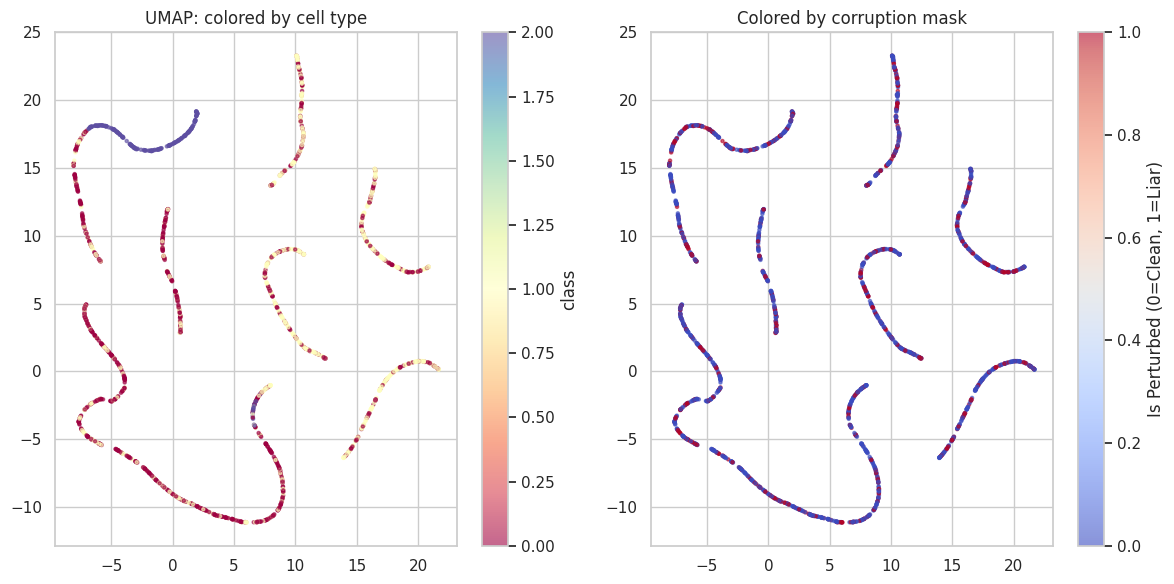

In [207]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(embedding[:,0],embedding[:,1],c=labels_sample['cell_type'],cmap="Spectral",s=5,alpha=0.6)
plt.title("UMAP: colored by cell type")
plt.colorbar(label='class')

plt.subplot(1,2,2)
plt.scatter(embedding[:,0],embedding[:,1],c=train_sample["is_perturbed"],cmap='coolwarm', s=5, alpha=0.6)
plt.title("Colored by corruption mask")
plt.colorbar(label='Is Perturbed (0=Clean, 1=Liar)')

plt.tight_layout()
plt.show()

In [208]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [209]:
valid_nodes = set(train['Unnamed: 0'].values)
mask = edges['source'].isin(valid_nodes) & edges['target'].isin(valid_nodes)
filtered_edges = edges[mask].copy()
node_id_map = {original_id: i for i,original_id in enumerate(train['Unnamed: 0'])}

In [210]:
filtered_edges['source'] = filtered_edges['source'].map(node_id_map)
filtered_edges['target'] = filtered_edges['target'].map(node_id_map)

In [211]:
feature_cols = [c for c in train.columns if c not in ['is_perturbed','Unnamed: 0']]
x = torch.tensor(train[feature_cols].values,dtype=torch.float)
perbutation_mask = torch.tensor(train['is_perturbed'].values, dtype=torch.float)
y = torch.tensor(labels['cell_type'],dtype=torch.long)

In [212]:
edge_index = torch.tensor(filtered_edges[['source', 'target']].values.T, dtype=torch.long)
edge_attr = torch.tensor(filtered_edges['weight'].values, dtype=torch.float)

In [213]:
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
data

Data(x=[3760, 1715], edge_index=[2, 17467], edge_attr=[17467], y=[3760])

In [214]:
data.perturbation_mask = torch.tensor(train['is_perturbed'].values, dtype=torch.bool)

In [215]:
num_nodes = data.num_nodes
indices = np.arange(num_nodes)
np.random.seed(SEED)
np.random.shuffle(indices)
train_size = int(0.8 * num_nodes)
data.train_mask = torch.zeros(num_nodes,dtype=torch.bool)
data.val_mask = torch.zeros(num_nodes,dtype=torch.bool)
data.train_mask[indices[:train_size]] = True
data.val_mask[indices[train_size:]] = True


In [216]:
print(f"Nodes = {data.num_nodes}  Edges = {data.num_edges}")
print(f"Trainset: {data.train_mask.sum().item()} nodes")
print(f"Valset: {data.val_mask.sum().item()} nodes")

Nodes = 3760  Edges = 17467
Trainset: 3008 nodes
Valset: 752 nodes


In [217]:
data.to(device)

Data(x=[3760, 1715], edge_index=[2, 17467], edge_attr=[17467], y=[3760], perturbation_mask=[3760], train_mask=[3760], val_mask=[3760])

In [218]:
class GCN(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels):
    super().__init__()
    self.conv1 = GCNConv(in_channels,hidden_channels)
    self.conv2 = GCNConv(hidden_channels,hidden_channels)
    self.conv3 = GCNConv(hidden_channels,out_channels)

  def forward(self,x,edge_index,edge_weight):
    x = self.conv1(x,edge_index,edge_weight)
    x = F.relu(x)
    x = F.dropout(x,p=0.5,training=self.training)
    x=self.conv2(x,edge_index,edge_weight)
    x = F.relu(x)
    x = F.dropout(x,p=0.5,training=self.training)
    x = self.conv3(x, edge_index, edge_weight)
    return x

In [219]:
model = GCN(data.num_features,64,3)
model.to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=0.01,weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

In [106]:
history = {
    'train_loss': [], "val_loss": [],
    'train_acc': [], 'val_acc': [],
    'epoch_time': []
}

patience = 20
best_val_acc = 0
best_epoch = 0
patience_counter = 0

total_start = time.time()
epochs = 100

for epoch in range(epochs):
    epoch_start = time.time()
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_attr.squeeze())
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index, data.edge_attr.squeeze())
        train_loss = criterion(out[data.train_mask], data.y[data.train_mask]).item()
        train_pred = out[data.train_mask].argmax(dim=1)
        train_acc = (train_pred == data.y[data.train_mask]).float().mean().item()

        val_loss = criterion(out[data.val_mask], data.y[data.val_mask]).item()
        val_pred = out[data.val_mask].argmax(dim=1)
        val_acc = (val_pred == data.y[data.val_mask]).float().mean().item()
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['epoch_time'].append(epoch_time)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), "best_gcn_model.pth")
    else:
        patience_counter += 1
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1:>5} | train_loss = {train_loss:>10.4f} | val_loss {val_loss:>10.4f} | val Acc {val_acc:>8.2%} | epoch time {epoch_time:>5.2f}s")
    if patience_counter >= patience:
        print(f"early stopping  epoch {epoch+1}  best val acc =  {best_val_acc:.2%}")
        break
total_time = time.time() - total_start
print(f"total training time =  {total_time:.2f}s")
print(f"best val accuracy =  {best_val_acc} ")

epoch    10 | train_loss =     0.7540 | val_loss     0.7530 | val Acc   67.55% | epoch time  0.11s
epoch    20 | train_loss =     0.6424 | val_loss     0.6633 | val Acc   75.93% | epoch time  0.11s
epoch    30 | train_loss =     0.5315 | val_loss     0.5790 | val Acc   78.32% | epoch time  0.13s
epoch    40 | train_loss =     0.4799 | val_loss     0.5447 | val Acc   77.13% | epoch time  0.11s
epoch    50 | train_loss =     0.4543 | val_loss     0.5476 | val Acc   77.53% | epoch time  0.16s
early stopping  epoch 53  best val acc =  78.46%
total training time =  6.73s
best val accuracy =  0.7845744490623474 


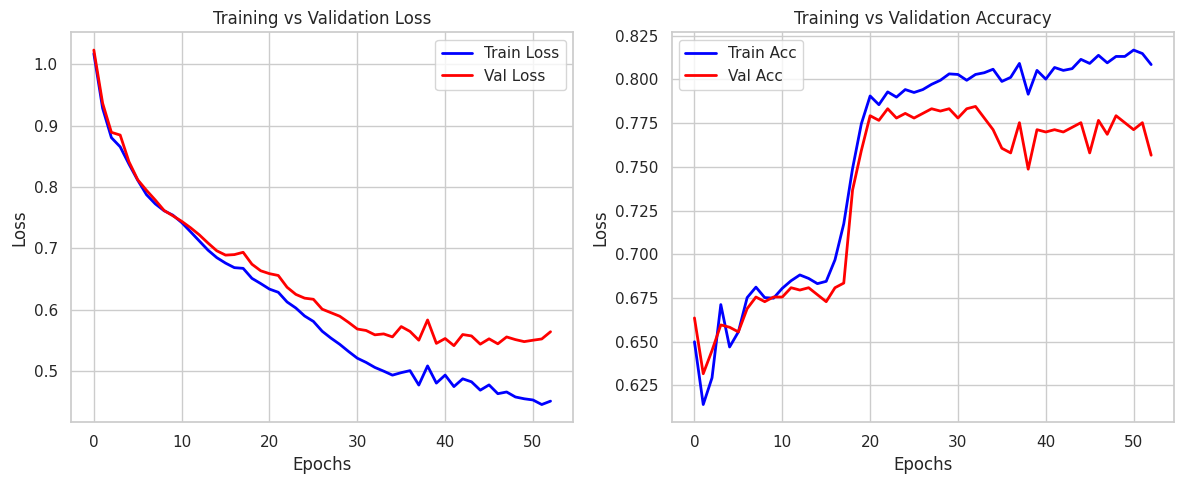

In [107]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(history['train_loss'],label='Train Loss',color='blue',lw=2)
ax[0].plot(history['val_loss'],label="Val Loss",color='red',lw=2)
ax[0].set_title('Training vs Validation Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()


ax[1].plot(history['train_acc'],label='Train Acc',color='blue',lw=2)
ax[1].plot(history['val_acc'],label="Val Acc",color='red',lw=2)
ax[1].set_title('Training vs Validation Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
plt.tight_layout()
plt.show()

In [108]:
model.load_state_dict(torch.load("best_gcn_model.pth"))

<All keys matched successfully>

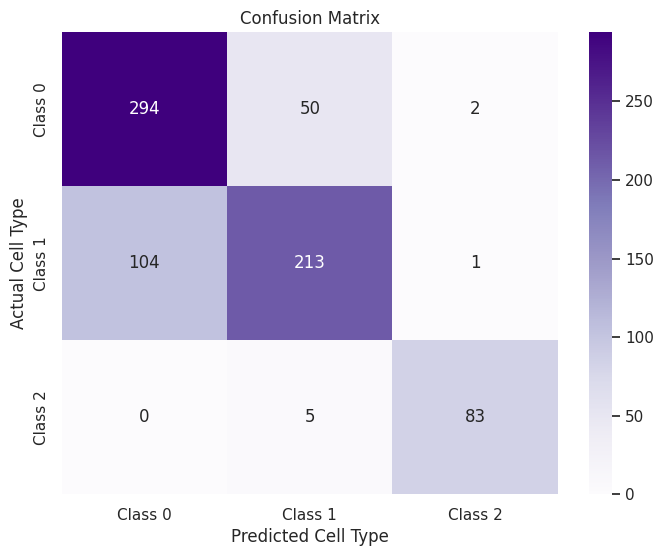

In [109]:
model.eval()
with torch.no_grad():
  out = model(data.x,data.edge_index, data.edge_attr.squeeze())
  y_pred = out[data.val_mask].argmax(dim=1).cpu().numpy()
  y_true = data.y[data.val_mask].cpu().numpy()

cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Cell Type")
plt.ylabel("Actual Cell Type")
plt.show()


In [110]:
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.85      0.79       346
           1       0.79      0.67      0.73       318
           2       0.97      0.94      0.95        88

    accuracy                           0.78       752
   macro avg       0.83      0.82      0.82       752
weighted avg       0.79      0.78      0.78       752



#GAT

In [111]:
class GAT(nn.Module):
  def __init__(self,in_channels,hidden_channels,output_channels,heads=4):
    super().__init__()
    self.conv1 = GATConv(in_channels,hidden_channels,heads=heads,dropout=0.6)
    self.conv2 = GATConv(hidden_channels * heads,output_channels,heads=1,concat=False, dropout=0.6)

  def forward(self,x,edge_index,edge_weight=None):
    x = F.dropout(x,p=0.6,training=self.training)
    x = self.conv1(x,edge_index)
    x = F.elu(x)

    x = F.dropout(x,p=0.6,training=self.training)
    x = self.conv2(x,edge_index)
    return x

In [112]:
model = GAT(data.num_features,32,3,heads=4)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

In [113]:
history = {
    'train_loss': [], "val_loss": [],
    'train_acc': [], 'val_acc': [],
    'epoch_time': []
}

patience = 20
best_val_acc = 0
best_epoch = 0
patience_counter = 0

total_start = time.time()
epochs = 100

for epoch in range(epochs):
    epoch_start = time.time()
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_attr.squeeze())
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index, data.edge_attr.squeeze())
        train_loss = criterion(out[data.train_mask], data.y[data.train_mask]).item()
        train_pred = out[data.train_mask].argmax(dim=1)
        train_acc = (train_pred == data.y[data.train_mask]).float().mean().item()

        val_loss = criterion(out[data.val_mask], data.y[data.val_mask]).item()
        val_pred = out[data.val_mask].argmax(dim=1)
        val_acc = (val_pred == data.y[data.val_mask]).float().mean().item()
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['epoch_time'].append(epoch_time)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), "best_gat_model.pth")
    else:
        patience_counter += 1
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1:>5} | train_loss = {train_loss:>10.4f} | val_loss {val_loss:>10.4f} | val Acc {val_acc:>8.2%} | epoch time {epoch_time:>5.2f}s")
    if patience_counter >= patience:
        print(f"early stopping  epoch {epoch+1}  best val acc =  {best_val_acc:.2%}")
        break
total_time = time.time() - total_start
print(f"total training time =  {total_time:.2f}s")
print(f"best val accuracy =  {best_val_acc} ")

epoch    10 | train_loss =     0.7695 | val_loss     0.7830 | val Acc   65.56% | epoch time  0.74s
epoch    20 | train_loss =     0.6903 | val_loss     0.6979 | val Acc   74.73% | epoch time  0.59s
epoch    30 | train_loss =     0.6149 | val_loss     0.6255 | val Acc   75.13% | epoch time  0.30s
epoch    40 | train_loss =     0.5896 | val_loss     0.5983 | val Acc   76.20% | epoch time  0.30s
epoch    50 | train_loss =     0.5802 | val_loss     0.5946 | val Acc   76.33% | epoch time  0.30s
early stopping  epoch 54  best val acc =  76.46%
total training time =  28.42s
best val accuracy =  0.7646276354789734 


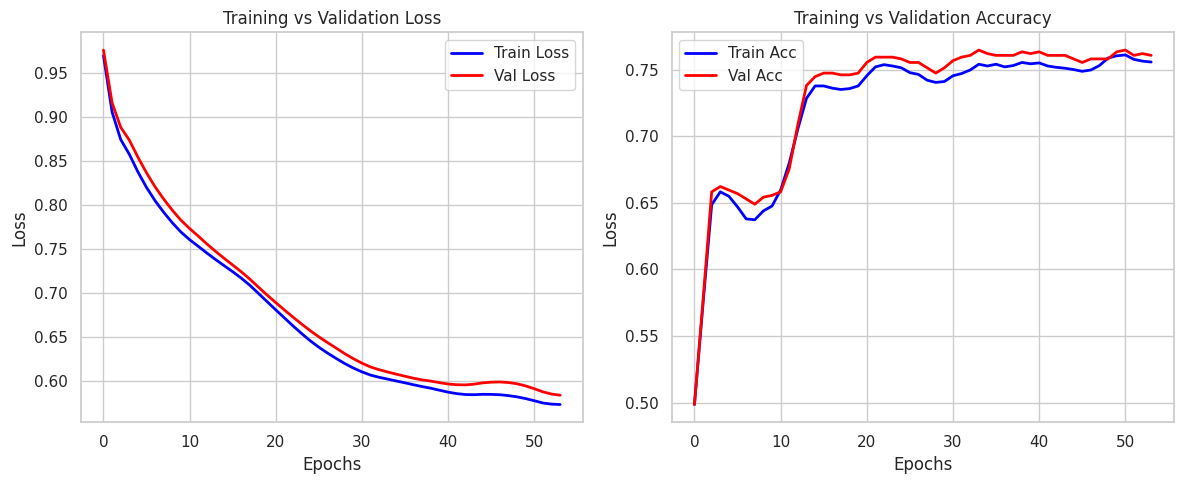

In [114]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(history['train_loss'],label='Train Loss',color='blue',lw=2)
ax[0].plot(history['val_loss'],label="Val Loss",color='red',lw=2)
ax[0].set_title('Training vs Validation Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()


ax[1].plot(history['train_acc'],label='Train Acc',color='blue',lw=2)
ax[1].plot(history['val_acc'],label="Val Acc",color='red',lw=2)
ax[1].set_title('Training vs Validation Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
plt.tight_layout()
plt.show()

In [115]:
model.load_state_dict(torch.load("best_gat_model.pth"))

<All keys matched successfully>

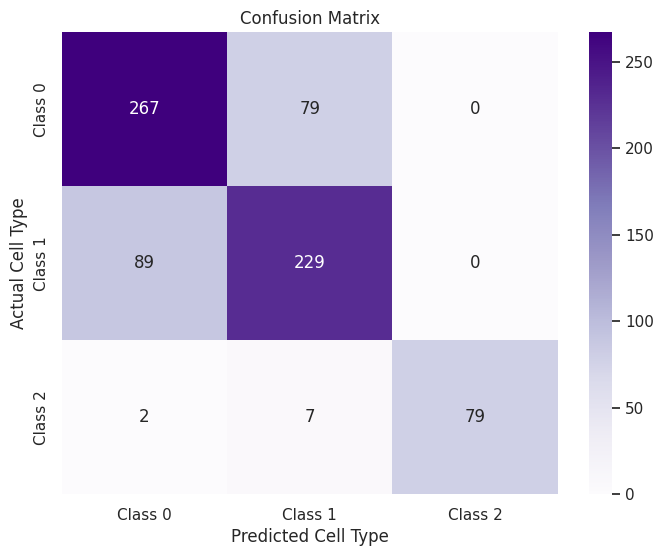

In [116]:
model.eval()
with torch.no_grad():
  out = model(data.x,data.edge_index, data.edge_attr.squeeze())
  y_pred = out[data.val_mask].argmax(dim=1).cpu().numpy()
  y_true = data.y[data.val_mask].cpu().numpy()

cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Cell Type")
plt.ylabel("Actual Cell Type")
plt.show()


In [117]:
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       346
           1       0.73      0.72      0.72       318
           2       1.00      0.90      0.95        88

    accuracy                           0.76       752
   macro avg       0.82      0.80      0.81       752
weighted avg       0.77      0.76      0.77       752



# Submission

In [242]:
all_node_ids = pd.concat([train['Unnamed: 0'], test['Unnamed: 0']]).unique()
node_id_map = {node_id: i for i, node_id in enumerate(all_node_ids)}
feature_cols = [c for c in train.columns if c not in ['is_perturbed', 'Unnamed: 0']]

I am using GCN because of its highest accuracy

In [244]:
x_train = train[['Unnamed: 0'] + feature_cols]
x_test = test[['Unnamed: 0'] + feature_cols]
x_combined = pd.concat([x_train, x_test]).drop_duplicates('Unnamed: 0')

In [245]:
x_combined['node_idx'] = x_combined['Unnamed: 0'].map(node_id_map)
x_combined = x_combined.sort_values('node_idx')
x_tensor = torch.tensor(x_combined[feature_cols].values, dtype=torch.float).to(device)

In [246]:
mask = edges['source'].isin(node_id_map) & edges['target'].isin(node_id_map)
full_edges = edges[mask].copy()
full_edges['source'] = full_edges['source'].map(node_id_map)
full_edges['target'] = full_edges['target'].map(node_id_map)

In [247]:
edge_index = torch.tensor(full_edges[['source', 'target']].values.T, dtype=torch.long).to(device)
edge_attr = torch.tensor(full_edges['weight'].values, dtype=torch.float).to(device)

In [248]:
model.load_state_dict(torch.load("best_gcn_model.pth"))

<All keys matched successfully>

In [251]:
model_infer = GCN(len(feature_cols), 64, 3).to(device)
model_infer.load_state_dict(torch.load("best_gcn_model.pth"))
model_infer.eval()
with torch.no_grad():

    logits = model_infer(x_tensor, edge_index, edge_attr)
    all_preds = logits.argmax(dim=1).cpu().numpy()
test_indices = [node_id_map[tid] for tid in test['Unnamed: 0']]
test_predictions = all_preds[test_indices]


In [252]:
submission = pd.DataFrame({
    'id': test['Unnamed: 0'],
    'target': test_predictions
})

submission.to_csv('submission.csv', index=False)